# Conflict & Music Culture Analysis

This notebook analyzes how conflict (Ukraine/Russia, Israel, Palestine, Syria) affects music culture by tracking:
- Where artists are born
- Where they move (exile)
- If their popularity (Wikipedia Pageviews) spikes during war

In [8]:
import requests, time, warnings
import pandas as pd
from urllib.parse import unquote, urlparse
from tqdm import tqdm
warnings.filterwarnings('ignore')

## Step 1: Wikidata Artist Extraction

Query Wikidata for **musicians, singers, rappers, composers, songwriters, DJs** from conflict regions:
- **Ukraine, Russia, Israel**: Birth place in country
- **Syria**: Birth place + citizenship (captures diaspora)
- **Palestine**: Citizenship + birth in West Bank/Gaza + Palestinian ethnicity (captures disputed territories)

Querying Ukraine...
  Found 500 artists
Querying Russia...
  Found 500 artists
Querying Israel...
  Found 500 artists
Querying Syria...
  Found 78 artists
Querying Palestine (by citizenship)...
  Found 31 artists

Total unique artists: 1574 - Trying to make the search better for the last two

In [7]:
WIKIDATA_ENDPOINT = "https://query.wikidata.org/sparql"
COUNTRIES = {"Q212": "Ukraine", "Q159": "Russia", "Q801": "Israel", "Q858": "Syria"}

def query_wikidata(query, country_name, retries=3):
    headers = {"Accept": "application/sparql-results+json", "User-Agent": "CSS-Project-A/1.0 (educational research)"}
    for attempt in range(retries):
        try:
            response = requests.get(WIKIDATA_ENDPOINT, params={"query": query}, headers=headers, timeout=90)
            if response.status_code == 429:
                wait = 30 * (attempt + 1)
                print(f"    Rate limited, waiting {wait}s...")
                time.sleep(wait)
                continue
            if response.status_code == 500:
                print(f"    Server error (query too complex?), waiting 10s...")
                time.sleep(10)
                continue
            if "error" in response.text.lower()[:500] or response.status_code >= 400:
                print(f"    API error (status {response.status_code}), retrying...")
                time.sleep(10)
                continue
            response.raise_for_status()
            data = response.json()
            return pd.DataFrame([{
                "name": item.get("artistLabel", {}).get("value", ""),
                "wikidata_id": item.get("artist", {}).get("value", "").split("/")[-1],
                "origin_country": country_name,
                "birth_place": item.get("birthPlaceLabel", {}).get("value", ""),
                "current_residence": item.get("residenceLabel", {}).get("value", ""),
                "wiki_url": item.get("article", {}).get("value", "")
            } for item in data["results"]["bindings"]])
        except Exception as e:
            print(f"    Error (attempt {attempt+1}/{retries}): {type(e).__name__}")
            if attempt < retries - 1:
                time.sleep(15)
    return pd.DataFrame()

def get_musicians(country_id, country_name):
    # Simplified query - just musician (Q639669) to avoid timeouts
    query = f"""SELECT DISTINCT ?artist ?artistLabel ?birthPlaceLabel ?residenceLabel ?article WHERE {{
      ?artist wdt:P106/wdt:P279* wd:Q639669 .
      ?artist wdt:P19 ?birthPlace . ?birthPlace wdt:P17 wd:{country_id} .
      ?article schema:about ?artist . ?article schema:isPartOf <https://en.wikipedia.org/> .
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en" . }} }} LIMIT 500"""
    return query_wikidata(query, country_name)

def get_palestinian_musicians():
    """Query Palestinian artists via multiple methods"""
    results = []
    
    # Method 1: Palestinian citizenship
    print("    - Citizenship query...")
    q1 = """SELECT DISTINCT ?artist ?artistLabel ?birthPlaceLabel ?residenceLabel ?article WHERE {
      ?artist wdt:P106/wdt:P279* wd:Q639669 . ?artist wdt:P27 wd:Q219060 .
      OPTIONAL { ?artist wdt:P19 ?birthPlace . }
      ?article schema:about ?artist . ?article schema:isPartOf <https://en.wikipedia.org/> .
      SERVICE wikibase:label { bd:serviceParam wikibase:language "en" . } } LIMIT 500"""
    results.append(query_wikidata(q1, "Palestine"))
    time.sleep(5)
    
    # Method 2: Palestinian ethnic group
    print("    - Ethnicity query...")
    q2 = """SELECT DISTINCT ?artist ?artistLabel ?birthPlaceLabel ?residenceLabel ?article WHERE {
      ?artist wdt:P106/wdt:P279* wd:Q639669 . ?artist wdt:P172 wd:Q178885 .
      OPTIONAL { ?artist wdt:P19 ?birthPlace . }
      ?article schema:about ?artist . ?article schema:isPartOf <https://en.wikipedia.org/> .
      SERVICE wikibase:label { bd:serviceParam wikibase:language "en" . } } LIMIT 500"""
    results.append(query_wikidata(q2, "Palestine"))
    
    return pd.concat(results, ignore_index=True).drop_duplicates(subset=["wikidata_id"])

def get_syrian_musicians():
    """Enhanced Syrian search: birth place + citizenship"""
    results = []
    
    # Method 1: Born in Syria
    print("    - Birth place query...")
    q1 = """SELECT DISTINCT ?artist ?artistLabel ?birthPlaceLabel ?residenceLabel ?article WHERE {
      ?artist wdt:P106/wdt:P279* wd:Q639669 .
      ?artist wdt:P19 ?birthPlace . ?birthPlace wdt:P17 wd:Q858 .
      ?article schema:about ?artist . ?article schema:isPartOf <https://en.wikipedia.org/> .
      SERVICE wikibase:label { bd:serviceParam wikibase:language "en" . } } LIMIT 500"""
    results.append(query_wikidata(q1, "Syria"))
    time.sleep(5)
    
    # Method 2: Syrian citizenship
    print("    - Citizenship query...")
    q2 = """SELECT DISTINCT ?artist ?artistLabel ?birthPlaceLabel ?residenceLabel ?article WHERE {
      ?artist wdt:P106/wdt:P279* wd:Q639669 . ?artist wdt:P27 wd:Q858 .
      OPTIONAL { ?artist wdt:P19 ?birthPlace . }
      ?article schema:about ?artist . ?article schema:isPartOf <https://en.wikipedia.org/> .
      SERVICE wikibase:label { bd:serviceParam wikibase:language "en" . } } LIMIT 500"""
    results.append(query_wikidata(q2, "Syria"))
    
    return pd.concat(results, ignore_index=True).drop_duplicates(subset=["wikidata_id"])

In [8]:
# Query standard countries (excluding Syria - has special function)
all_artists = []
standard_countries = {k: v for k, v in COUNTRIES.items() if v != "Syria"}

for country_id, country_name in standard_countries.items():
    print(f"Querying {country_name}...")
    df = get_musicians(country_id, country_name)
    print(f"  Found {len(df)} artists")
    all_artists.append(df)
    time.sleep(5)  # Longer delay to avoid rate limiting

# Enhanced Syria search (birth place + citizenship)
print(f"Querying Syria (enhanced: birth place + citizenship)...")
df_syria = get_syrian_musicians()
print(f"  Found {len(df_syria)} unique artists")
all_artists.append(df_syria)
time.sleep(5)

# Enhanced Palestine search (citizenship + territories + ethnicity)
print(f"Querying Palestine (enhanced: citizenship + territories + ethnicity)...")
df_palestine = get_palestinian_musicians()
print(f"  Found {len(df_palestine)} unique artists")
all_artists.append(df_palestine)

artists_df = pd.concat(all_artists, ignore_index=True).drop_duplicates(subset=["wikidata_id"])
print(f"\nTotal unique artists: {len(artists_df)}")
artists_df.head(10)

Querying Ukraine...
    API error (status 504), retrying...
  Found 500 artists
Querying Russia...
  Found 500 artists
Querying Israel...
  Found 500 artists
Querying Syria (enhanced: birth place + citizenship)...
    - Birth place query...
    API error (status 504), retrying...
    - Citizenship query...
  Found 87 unique artists
Querying Palestine (enhanced: citizenship + territories + ethnicity)...
    - Citizenship query...
    - Ethnicity query...
  Found 31 unique artists

Total unique artists: 1583


,name,wikidata_id,origin_country,birth_place,current_residence,wiki_url
0,Vladimir Horowitz,Q192506,Ukraine,Kyiv,,https://en.wikipedia.org/wiki/Vladimir_Horowitz
1,Milla Jovovich,Q170576,Ukraine,Kyiv,,https://en.wikipedia.org/wiki/Milla_Jovovich
2,Sergei Prokofiev,Q49481,Ukraine,Sontsivka,,https://en.wikipedia.org/wiki/Sergei_Prokofiev
3,Pavel Gililov,Q107449,Ukraine,Donetsk,,https://en.wikipedia.org/wiki/Pavel_Gililov
4,Moriz Rosenthal,Q213772,Ukraine,Lviv,,https://en.wikipedia.org/wiki/Moriz_Rosenthal
5,Władysław Tarnowski,Q93817,Ukraine,Voroblevychi,,https://en.wikipedia.org/wiki/W%C5%82adys%C5%8...
6,Norbert Glanzberg,Q213834,Ukraine,Rohatyn,,https://en.wikipedia.org/wiki/Norbert_Glanzberg
7,Eduard Steuermann,Q214108,Ukraine,Sambir,,https://en.wikipedia.org/wiki/Eduard_Steuermann
8,Taras Chubay,Q82262,Ukraine,Lviv,,https://en.wikipedia.org/wiki/Taras_Chubay
9,Aleksander Serov,Q4417712,Ukraine,Kovalivka,,https://en.wikipedia.org/wiki/Aleksander_Serov


## World Map Visualization TODO

Plot artists on a world map based on their birth place and current residence.

In [ ]:
# # Initialize geocoder with rate limiting
# geolocator = Nominatim(user_agent="css_project_music_analysis")
# geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# # Cache for geocoded locations to avoid repeated API calls
# location_cache = {}

# def get_coordinates(place_name):
#     """Get latitude and longitude for a place name."""
#     if not place_name or pd.isna(place_name) or place_name == "":
#         return None, None
    
#     # Check cache first
#     if place_name in location_cache:
#         return location_cache[place_name]
    
#     try:
#         location = geocode(place_name)
#         if location:
#             coords = (location.latitude, location.longitude)
#             location_cache[place_name] = coords
#             return coords
#         else:
#             location_cache[place_name] = (None, None)
#             return None, None
#     except Exception as e:
#         print(f"Error geocoding {place_name}: {e}")
#         location_cache[place_name] = (None, None)
#         return None, None

# print("Geocoding functions ready!")

Geocoding functions ready!


In [ ]:
# # Geocode birth places (this may take a while due to rate limiting)
# print("Geocoding birth places... This may take a few minutes.")

# # Get unique places to minimize API calls
# unique_birth_places = artists_df["birth_place"].dropna().unique()
# print(f"Found {len(unique_birth_places)} unique birth places to geocode.")

# # Geocode each unique place
# for i, place in enumerate(tqdm(unique_birth_places, desc="Geocoding")):
#     get_coordinates(place)
    
# print(f"\nGeocoded {len(location_cache)} locations.")

Geocoding birth places... This may take a few minutes.
Found 262 unique birth places to geocode.


Geocoding: 100%|██████████| 262/262 [04:21<00:00,  1.00it/s]


Geocoded 262 locations.


In [ ]:
# # Add coordinates to the dataframe
# artists_df["latitude"] = artists_df["birth_place"].apply(lambda x: get_coordinates(x)[0] if x else None)
# artists_df["longitude"] = artists_df["birth_place"].apply(lambda x: get_coordinates(x)[1] if x else None)

# # Check how many artists have valid coordinates
# valid_coords = artists_df.dropna(subset=["latitude", "longitude"])
# print(f"Artists with valid coordinates: {len(valid_coords)} out of {len(artists_df)}")

Artists with valid coordinates: 1169 out of 1183


In [ ]:
# # Add coordinates to the dataframe
# artists_df["latitude"] = artists_df["birth_place"].apply(lambda x: get_coordinates(x)[0] if x else None)
# artists_df["longitude"] = artists_df["birth_place"].apply(lambda x: get_coordinates(x)[1] if x else None)

# # Check how many artists have valid coordinates
# valid_coords = artists_df.dropna(subset=["latitude", "longitude"])
# print(f"Artists with valid coordinates: {len(valid_coords)} out of {len(artists_df)}")

Artists with valid coordinates: 1169 out of 1183


In [ ]:
# # Create an interactive world map
# # Center the map on Europe/Middle East region
# world_map = folium.Map(location=[40, 40], zoom_start=3, tiles="CartoDB positron")

# # Color mapping for countries
# country_colors = {
#     "Ukraine": "blue",
#     "Russia": "red",
#     "Iran": "green",
#     "Palestine": "orange",
#     "Syria": "purple"
# }

# # Add markers for each artist
# for idx, row in valid_coords.iterrows():
#     color = country_colors.get(row["origin_country"], "gray")
    
#     # Create popup with artist info
#     popup_html = f"""
#     <b>{row['name']}</b><br>
#     Country: {row['origin_country']}<br>
#     Birth Place: {row['birth_place']}<br>
#     <a href="{row['wiki_url']}" target="_blank">Wikipedia</a>
#     """
    
#     folium.CircleMarker(
#         location=[row["latitude"], row["longitude"]],
#         radius=6,
#         color=color,
#         fill=True,
#         fill_color=color,
#         fill_opacity=0.7,
#         popup=folium.Popup(popup_html, max_width=300),
#         tooltip=row["name"]
#     ).add_to(world_map)

# # Add a legend
# legend_html = """
# <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; 
#             background-color: white; padding: 10px; border: 2px solid gray; border-radius: 5px;">
#     <b>Origin Country</b><br>
#     <i style="background: blue; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Ukraine<br>
#     <i style="background: red; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Russia<br>
#     <i style="background: green; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Iran<br>
#     <i style="background: orange; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Palestine<br>
#     <i style="background: purple; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Syria
# </div>
# """
# world_map.get_root().html.add_child(folium.Element(legend_html))

# print("Interactive map created! Click on markers for artist details.")
# world_map

Interactive map created! Click on markers for artist details.


In [ ]:
# # Create an interactive world map
# # Center the map on Europe/Middle East region
# world_map = folium.Map(location=[40, 40], zoom_start=3, tiles="CartoDB positron")

# # Color mapping for countries
# country_colors = {
#     "Ukraine": "blue",
#     "Russia": "red",
#     "Iran": "green",
#     "Palestine": "orange",
#     "Syria": "purple"
# }

# # Add markers for each artist
# for idx, row in valid_coords.iterrows():
#     color = country_colors.get(row["origin_country"], "gray")
    
#     # Create popup with artist info
#     popup_html = f"""
#     <b>{row['name']}</b><br>
#     Country: {row['origin_country']}<br>
#     Birth Place: {row['birth_place']}<br>
#     <a href="{row['wiki_url']}" target="_blank">Wikipedia</a>
#     """
    
#     folium.CircleMarker(
#         location=[row["latitude"], row["longitude"]],
#         radius=6,
#         color=color,
#         fill=True,
#         fill_color=color,
#         fill_opacity=0.7,
#         popup=folium.Popup(popup_html, max_width=300),
#         tooltip=row["name"]
#     ).add_to(world_map)

# # Add a legend
# legend_html = """
# <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; 
#             background-color: white; padding: 10px; border: 2px solid gray; border-radius: 5px;">
#     <b>Origin Country</b><br>
#     <i style="background: blue; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Ukraine<br>
#     <i style="background: red; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Russia<br>
#     <i style="background: green; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Iran<br>
#     <i style="background: orange; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Palestine<br>
#     <i style="background: purple; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Syria
# </div>
# """
# world_map.get_root().html.add_child(folium.Element(legend_html))

# print("Interactive map created! Click on markers for artist details.")
# world_map

Interactive map created! Click on markers for artist details.


In [ ]:
# # Save the map as an HTML file (can be opened in any browser)
# world_map.save("artists_world_map.html")
# print("Map saved to: artists_world_map.html")

Map saved to: artists_world_map.html


## Step 2: Enrich Residence Data
Fill `current_residence` using hierarchy: residence > work_location > citizenship > educated_at > birth_place

In [9]:
def enrich_artist_locations(wikidata_ids, batch_size=50):
    all_results = []
    headers = {"Accept": "application/sparql-results+json", "User-Agent": "CSS-Project-A/1.0"}
    for i in range(0, len(wikidata_ids), batch_size):
        ids_str = " ".join([f"wd:{wid}" for wid in wikidata_ids[i:i+batch_size]])
        query = f"""SELECT DISTINCT ?artist ?residenceLabel ?workLocationLabel ?citizenshipLabel ?educatedAtLocationLabel WHERE {{
          VALUES ?artist {{ {ids_str} }}
          OPTIONAL {{ ?artist wdt:P551 ?residence . }} OPTIONAL {{ ?artist wdt:P937 ?workLocation . }}
          OPTIONAL {{ ?artist wdt:P27 ?citizenship . }}
          OPTIONAL {{ ?artist wdt:P69 ?school . ?school wdt:P131*/wdt:P17? ?educatedAtLocation .
            FILTER(EXISTS {{ ?educatedAtLocation wdt:P31/wdt:P279* wd:Q6256 }} || EXISTS {{ ?educatedAtLocation wdt:P31/wdt:P279* wd:Q515 }}) }}
          SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en" . }} }}"""
        try:
            data = requests.get(WIKIDATA_ENDPOINT, params={"query": query}, headers=headers, timeout=60).json()
            all_results.extend([{"wikidata_id": item.get("artist", {}).get("value", "").split("/")[-1],
                "residence": item.get("residenceLabel", {}).get("value", ""),
                "work_location": item.get("workLocationLabel", {}).get("value", ""),
                "citizenship": item.get("citizenshipLabel", {}).get("value", ""),
                "educated_at_location": item.get("educatedAtLocationLabel", {}).get("value", "")
            } for item in data["results"]["bindings"]])
        except Exception as e: print(f"Batch error: {e}")
        time.sleep(1)
    return pd.DataFrame(all_results)

In [10]:
enriched_df = enrich_artist_locations(artists_df["wikidata_id"].tolist())
enriched_agg = enriched_df.groupby("wikidata_id").agg({col: lambda x: "; ".join(sorted(set(filter(None, x)))) 
    for col in ["residence", "work_location", "citizenship", "educated_at_location"]}).reset_index()

before = (artists_df["current_residence"].notna() & (artists_df["current_residence"] != "")).sum()
artists_df = artists_df.merge(enriched_agg, on="wikidata_id", how="left", suffixes=("", "_enriched"))

# Fill current_residence: residence > work_location > citizenship > educated_at > birth_place
for idx, row in artists_df.iterrows():
    for col in ["residence", "current_residence", "work_location", "citizenship", "educated_at_location", "birth_place"]:
        val = row.get(col) if col != "current_residence" else row.get("current_residence")
        if pd.notna(val) and val:
            artists_df.at[idx, "current_residence"] = str(val).split(";")[0].strip()
            break

after = (artists_df["current_residence"].notna() & (artists_df["current_residence"] != "")).sum()
print(f"Residence fill: {before} -> {after} (+{after - before})")

Residence fill: 0 -> 1583 (+1583)


In [11]:
artists_df[["name", "wikidata_id", "origin_country", "birth_place", "current_residence", "wiki_url"]].to_csv("artists_data.csv", index=False)
print(f"Saved {len(artists_df)} artists to artists_data.csv")

Saved 1583 artists to artists_data.csv


## Step 3: Collect Wikipedia Pageviews
Monthly pageviews to analyze popularity changes **before vs after each conflict**:

| Country | Conflict Date | Data Range | Notes |
|---------|--------------|------------|-------|
| Ukraine/Russia | Feb 2022 | 2021-2024 | Good before/after coverage |
| Israel/Palestine | Oct 2023 | 2021-2025 | Extended to capture post-conflict |
| Syria | Mar 2011 | 2015-2020 | API limit: no pre-2015 data available |

In [5]:
# Conflict dates and custom date ranges for each region
# Wikipedia Pageviews API available from July 2015
CONFLICT_DATES = {
    "Ukraine": "2022-02-24",   # 2021-2024: ~13mo before, ~22mo after
    "Russia": "2022-02-24",
    "Syria": "2011-03-15",     # 2015-2020: all post-conflict (can't get pre-2011 data)
    "Israel": "2023-10-07",    # 2021-2025: ~33mo before, ~15mo after  
    "Palestine": "2023-10-07"
}

# Country-specific date ranges to capture before/after conflict periods
DATE_RANGES = {
    "Ukraine": ("20210101", "20241231"),
    "Russia": ("20210101", "20241231"),
    "Syria": ("20150701", "20201231"),      # All post-conflict, but shows trends
    "Israel": ("20210101", "20251231"),
    "Palestine": ("20210101", "20251231")
}

def get_monthly_pageviews(title, start="20210101", end="20231231"):
    if not title: return {}
    url = f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/all-agents/{requests.utils.quote(title.replace(' ', '_'), safe='')}/monthly/{start}/{end}"
    try:
        data = requests.get(url, headers={"User-Agent": "CSS-Project-A/1.0"}, timeout=30).json()
        return {f"{i['timestamp'][:4]}-{i['timestamp'][4:6]}": i["views"] for i in data.get("items", [])}
    except: return {}

In [9]:
# Load artists from CSV (avoids re-running Wikidata queries)
artists_df = pd.read_csv("artists_data.csv")
artists_df["wiki_title"] = artists_df["wiki_url"].apply(lambda u: unquote(urlparse(u).path.split("/")[-1]) if u else None)
print(f"Loaded {len(artists_df)} artists from CSV")
artists_df[["name", "origin_country", "wiki_title"]].head()

Loaded 1583 artists from CSV


,name,origin_country,wiki_title
0,Vladimir Horowitz,Ukraine,Vladimir_Horowitz
1,Milla Jovovich,Ukraine,Milla_Jovovich
2,Sergei Prokofiev,Ukraine,Sergei_Prokofiev
3,Pavel Gililov,Ukraine,Pavel_Gililov
4,Moriz Rosenthal,Ukraine,Moriz_Rosenthal


In [15]:
# Fetch pageviews using country-specific date ranges
all_monthly_data = []
errors_by_country = {c: 0 for c in DATE_RANGES.keys()}

for idx, row in tqdm(artists_df.iterrows(), total=len(artists_df), desc="Fetching pageviews"):
    country = row["origin_country"]
    start, end = DATE_RANGES.get(country, ("20210101", "20231231"))
    
    pageviews = get_monthly_pageviews(row["wiki_title"], start, end)
    if not pageviews:
        errors_by_country[country] = errors_by_country.get(country, 0) + 1
        continue
        
    for month, views in pageviews.items():
        all_monthly_data.append({
            "wikidata_id": row["wikidata_id"], 
            "name": row["name"], 
            "origin_country": country, 
            "month": month, 
            "views": views
        })
    time.sleep(0.05) 

print(f"\nErrors per country:")
for country, err in errors_by_country.items():
    total = len(artists_df[artists_df["origin_country"] == country])
    print(f"  {country}: {err}/{total} failed")

if all_monthly_data:
    monthly_df = pd.DataFrame(all_monthly_data)
    totals = monthly_df.groupby("wikidata_id")["views"].sum()
    artists_df["total_views"] = artists_df["wikidata_id"].map(totals).fillna(0).astype(int)
    
    print(f"\nMonthly records: {len(monthly_df)}")
    print(f"\nRecords per country:")
    for country, (start, end) in DATE_RANGES.items():
        count = len(monthly_df[monthly_df["origin_country"] == country])
        print(f"  {country}: {count} records")
else:
    print("⚠️  No pageview data collected!")
    monthly_df = pd.DataFrame(columns=["wikidata_id", "name", "origin_country", "month", "views"])

Fetching pageviews: 100%|██████████| 1583/1583 [04:58<00:00,  5.30it/s]


Errors per country:
  Ukraine: 287/494 failed
  Russia: 488/490 failed
  Syria: 62/86 failed
  Israel: 341/490 failed
  Palestine: 14/23 failed

Monthly records: 19869

Records per country:
  Ukraine: 9426 records
  Russia: 96 records
  Syria: 1491 records
  Israel: 8316 records
  Palestine: 540 records


In [16]:
print("Pageviews BEFORE vs AFTER conflict:\n")
for country, conflict_date in CONFLICT_DATES.items():
    cd = monthly_df[monthly_df["origin_country"] == country]
    start, end = DATE_RANGES.get(country, ("20210101", "20231231"))
    
    print(f"{country} (conflict: {conflict_date}, data: {start[:4]}-{end[:4]}):")
    
    if len(cd) == 0:
        print("  No pageview data found\n")
        continue
    
    cm = conflict_date[:7]  # e.g., "2022-02"
    before_data = cd[cd["month"] < cm]
    after_data = cd[cd["month"] >= cm]
    
    before, after = before_data["views"].sum(), after_data["views"].sum()
    mb, ma = len(before_data["month"].unique()), len(after_data["month"].unique())
    
    print(f"  Data range: {cd['month'].min()} to {cd['month'].max()}")
    print(f"  BEFORE ({mb} months): {before:,} total views")
    print(f"  AFTER  ({ma} months): {after:,} total views")
    
    if mb > 0 and ma > 0:
        ab, aa = before/mb, after/ma
        change_pct = (aa - ab) / ab * 100 if ab > 0 else 0
        print(f"  Avg: {ab:,.0f}/mo -> {aa:,.0f}/mo ({change_pct:+.1f}% change)")
    elif mb == 0:
        print(f"Conflict predates available data - all data is post-conflict")
    elif ma == 0:
        print(f"Conflict postdates data range - all data is pre-conflict")
    print()

Pageviews BEFORE vs AFTER conflict:

Ukraine (conflict: 2022-02-24, data: 2021-2024):
  Data range: 2021-01 to 2024-12
  BEFORE (13 months): 6,588,677 total views
  AFTER  (35 months): 18,685,232 total views
  Avg: 506,821/mo -> 533,864/mo (+5.3% change)

Russia (conflict: 2022-02-24, data: 2021-2024):
  Data range: 2021-01 to 2024-12
  BEFORE (13 months): 1,618,725 total views
  AFTER  (35 months): 4,739,275 total views
  Avg: 124,517/mo -> 135,408/mo (+8.7% change)

Syria (conflict: 2011-03-15, data: 2015-2020):
  Data range: 2015-07 to 2020-12
  BEFORE (0 months): 0 total views
  AFTER  (66 months): 1,938,075 total views
Conflict predates available data - all data is post-conflict

Israel (conflict: 2023-10-07, data: 2021-2025):
  Data range: 2021-01 to 2025-12
  BEFORE (33 months): 5,209,107 total views
  AFTER  (27 months): 5,421,276 total views
  Avg: 157,852/mo -> 200,788/mo (+27.2% change)

Palestine (conflict: 2023-10-07, data: 2021-2025):
  Data range: 2021-01 to 2025-12
  BE

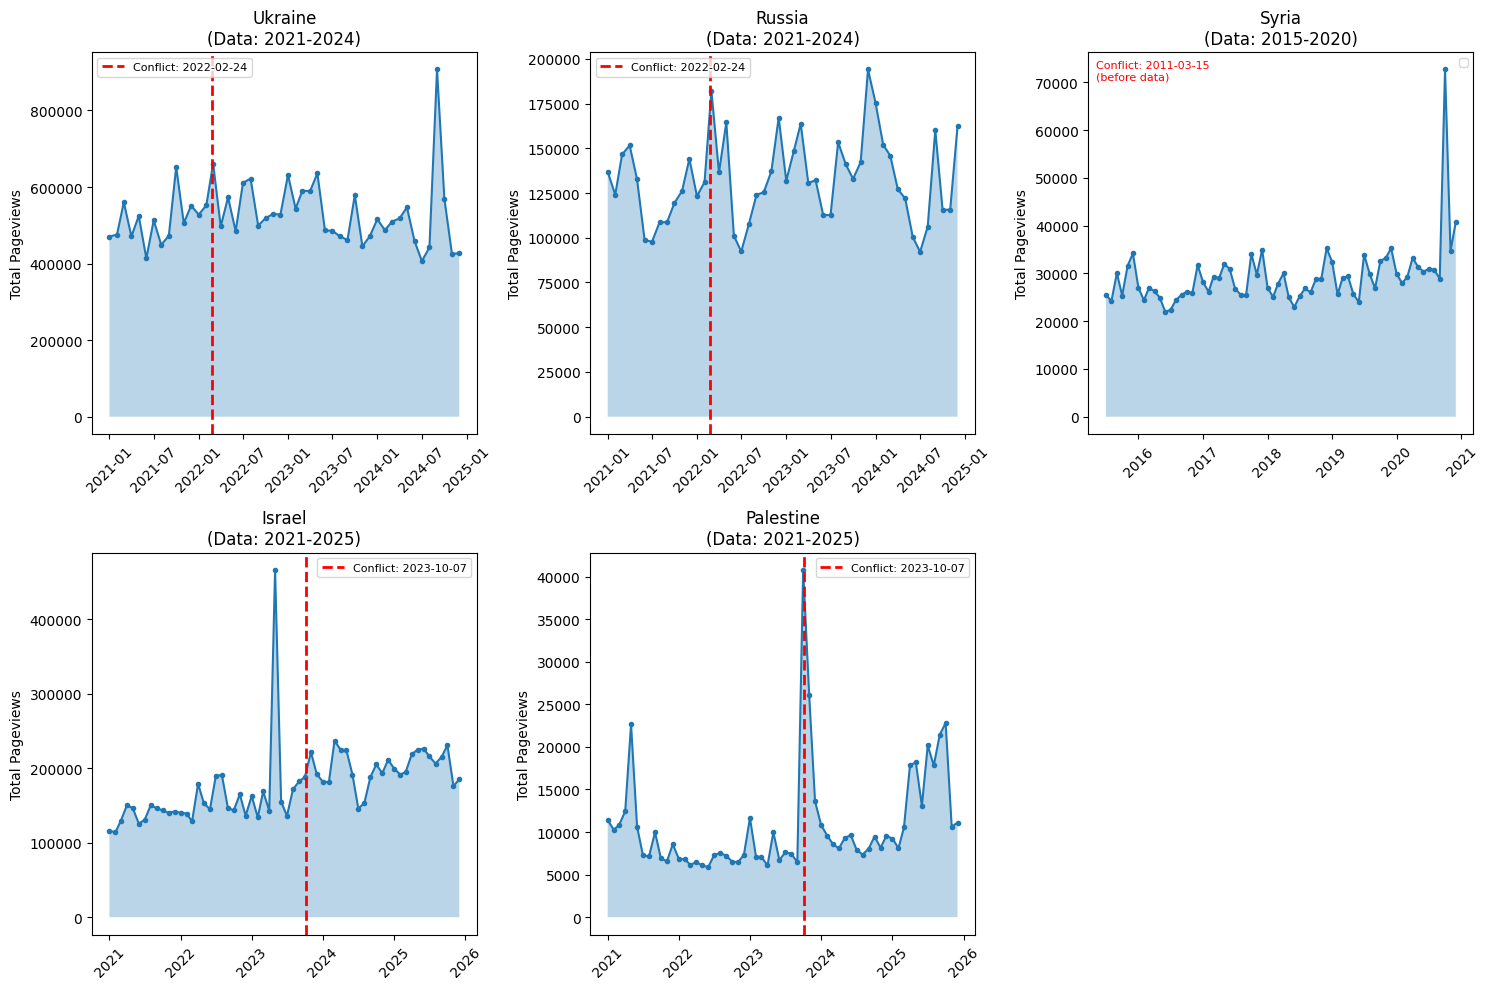

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, (country, conflict_date) in enumerate(CONFLICT_DATES.items()):
    ax = axes.flatten()[i]
    cd = monthly_df[monthly_df["origin_country"] == country]
    
    if len(cd) == 0: 
        ax.text(0.5, 0.5, f"No data", ha='center', va='center')
        ax.set_title(country)
        continue
    
    mt = cd.groupby("month")["views"].sum().sort_index()
    dates = [datetime.strptime(m, "%Y-%m") for m in mt.index]
    
    ax.plot(dates, mt.values, marker='o', markersize=3)
    ax.fill_between(dates, mt.values, alpha=0.3)
    
    # Only show conflict line if it falls within the data range
    conflict_dt = datetime.strptime(conflict_date, "%Y-%m-%d")
    if min(dates) <= conflict_dt <= max(dates):
        ax.axvline(conflict_dt, color='red', linestyle='--', linewidth=2, label=f'Conflict: {conflict_date}')
    else:
        # Conflict outside data range - add annotation
        if conflict_dt < min(dates):
            ax.annotate(f'Conflict: {conflict_date}\n(before data)', xy=(0.02, 0.98), 
                       xycoords='axes fraction', fontsize=8, color='red', va='top')
        else:
            ax.annotate(f'Conflict: {conflict_date}\n(after data)', xy=(0.98, 0.98), 
                       xycoords='axes fraction', fontsize=8, color='red', va='top', ha='right')
    
    start, end = DATE_RANGES.get(country, ("20210101", "20231231"))
    ax.set_title(f"{country}\n(Data: {start[:4]}-{end[:4]})")
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel("Total Pageviews")

axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.savefig("pageviews_by_conflict.png", dpi=150)
plt.show()